# Target Analysis — Bank Marketing Dataset

## Objective

Analyze the target variable (`y`) to understand:

- class distribution
- class imbalance
- baseline performance
- implications for model evaluation

Understanding the target distribution is essential before building predictive models.

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10,6)

In [4]:
df = pd.read_csv("../data/raw/bank-full.csv", sep=";")

df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [5]:
df["y"].value_counts()

y
no     39922
yes     5289
Name: count, dtype: int64

In [6]:
df["y"].value_counts(normalize=True)

y
no     0.883015
yes    0.116985
Name: proportion, dtype: float64

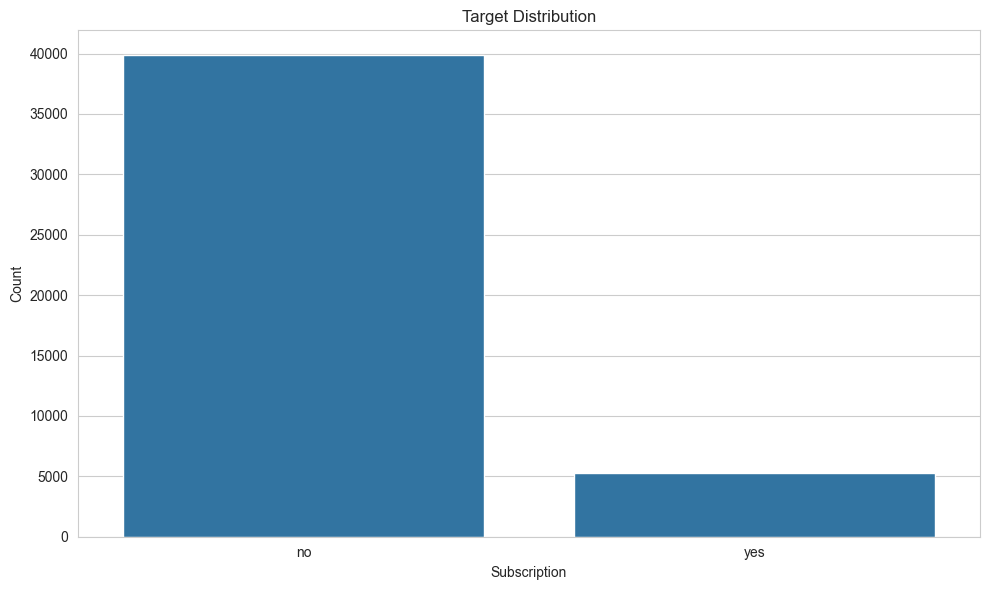

In [7]:
sns.countplot(data=df, x="y")

plt.title("Target Distribution")
plt.xlabel("Subscription")
plt.ylabel("Count")

plt.tight_layout()

plt.savefig("../reports/figures/target_distribution.png")

plt.show()

In [8]:
class_counts = df["y"].value_counts()

imbalance_ratio = class_counts["no"] / class_counts["yes"]

imbalance_ratio

np.float64(7.548118737001324)

The dataset shows a class imbalance of approximately **7.5:1**.

This means that for every client who subscribes, there are roughly 7 clients who do not.

In [6]:
baseline_accuracy = df["y"].value_counts(normalize=True).max()

baseline_accuracy

np.float64(0.8830151954170445)

A naive model predicting **"no" for every client** would achieve an accuracy of **88.3%**.

Therefore:

Accuracy alone is not an appropriate metric for this problem.

## Implications for Model Evaluation

Due to the class imbalance, accuracy is not an informative metric.

Instead, we will prioritize the following metrics:

Primary metric:
- ROC-AUC

Secondary metrics:
- Recall
- Precision
- F1-score

These metrics better capture the model's ability to detect the minority class (clients who subscribe).

## Business Interpretation

The positive class ("yes") represents clients who subscribe to a term deposit.

From a business perspective:

- Identifying potential subscribers is valuable.
- Missing a potential subscriber may represent a lost opportunity.

Therefore, recall for the positive class will also be considered during evaluation.

In [7]:
target_summary = pd.DataFrame({
    
    "metric": [
        "total_samples",
        "positive_class",
        "negative_class",
        "positive_rate",
        "baseline_accuracy"
    ],
    
    "value": [
        len(df),
        (df["y"]=="yes").sum(),
        (df["y"]=="no").sum(),
        round((df["y"]=="yes").mean(),3),
        round(baseline_accuracy,3)
    ]
    
})

target_summary

,metric,value
0,total_samples,45211.000
1,positive_class,5289.000
2,negative_class,39922.000
3,positive_rate,0.117
4,baseline_accuracy,0.883


## Key Findings

- Dataset size: 45,211 observations
- Positive class ("yes"): ~11.7%
- Negative class ("no"): ~88.3%
- Class imbalance ratio: ~7.5:1

A naive classifier predicting only the majority class would achieve ~88% accuracy.

Therefore, accuracy will not be used as the primary metric.

The main evaluation metric will be **ROC-AUC**.